# Análise dos Datasets — Projeto de Qualidade do Sono

Este notebook reúne a análise exploratória dos dois datasets utilizados no projeto e documenta a estratégia final adotada:

- **Classificação:** utiliza o dataset principal de saúde do sono combinado com uma amostra do dataset mobile/comportamental.
- **Regressão:** utiliza apenas o dataset mobile/comportamental para estimar o `sleep_quality_score`.

A classificação tem como objetivo prever `Insomnia`, `Sleep Apnea` ou `No Disorder`. A regressão tem como objetivo gerar um score de qualidade do sono.

## 1. Imports e configurações

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

pd.set_option("display.max_columns", None)

## 2. Carregamento dos datasets

In [46]:
DATASET_SLEEP_PATH = "Sleep_health_and_lifestyle_dataset.csv"
DATASET_MOBILE_PATH = "sleep_mobile_stress_dataset_15000.csv"

sleep_df = pd.read_csv(DATASET_SLEEP_PATH)
mobile_df = pd.read_csv(DATASET_MOBILE_PATH)

print("Dataset principal de sono/saúde:", sleep_df.shape)
print("Dataset mobile/comportamental:", mobile_df.shape)

Dataset principal de sono/saúde: (374, 13)
Dataset mobile/comportamental: (15000, 13)


## 3. Análise do dataset principal de sono/saúde

Este dataset contém dados fisiológicos e de estilo de vida, como duração do sono, qualidade do sono, nível de estresse, pressão arterial, batimentos cardíacos, passos diários e distúrbio do sono.

In [47]:
sleep_df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [48]:
sleep_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [49]:
sleep_df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [50]:
sleep_df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

### 3.1 Distribuição da variável alvo original

No dataset original, os valores ausentes de `Sleep Disorder` foram interpretados como `No Disorder` para permitir a classificação em três classes.

In [51]:
sleep_target = sleep_df["Sleep Disorder"].fillna("No Disorder")
sleep_target.value_counts()

Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

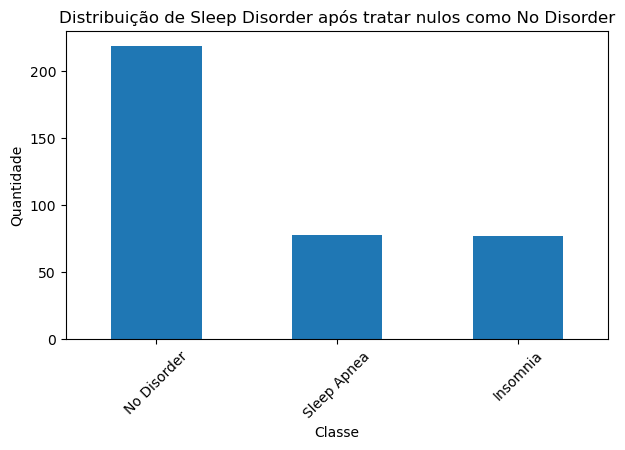

In [52]:
sleep_target.value_counts().plot(kind="bar", figsize=(7,4))
plt.title("Distribuição de Sleep Disorder após tratar nulos como No Disorder")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

### 3.2 Correlação entre variáveis numéricas do dataset principal

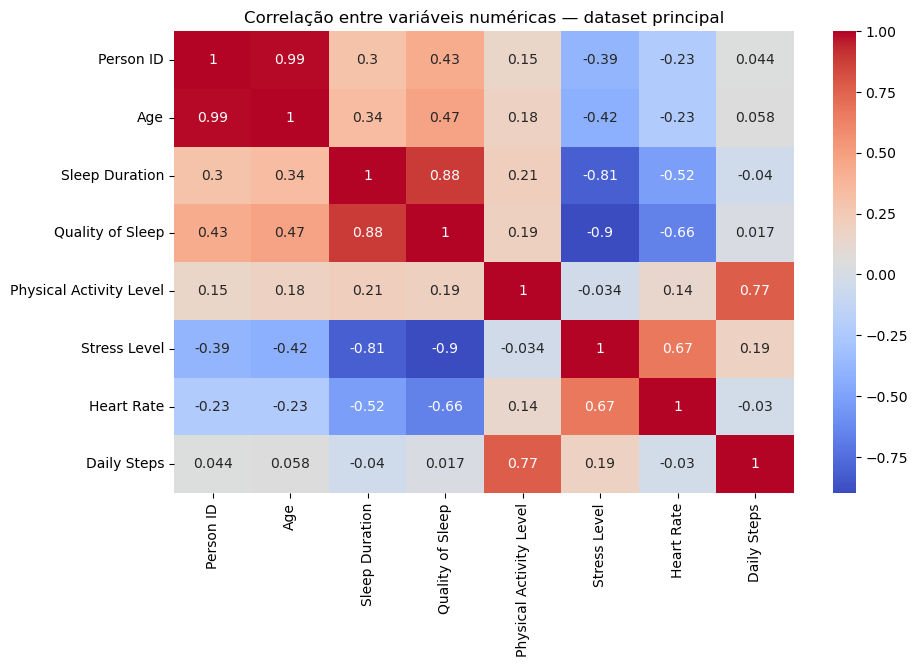

In [53]:
sleep_numeric = sleep_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(sleep_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis numéricas — dataset principal")
plt.show()

### 3.3 Tratamento da pressão arterial

A pressão arterial originalmente vem no formato `120/80`. Para simplificar a coleta no app e reduzir a quantidade de features, foi criada uma variável única de pressão média:

`bp_mean = (sistólica + 2 × diastólica) / 3`

Nos testes, essa simplificação manteve desempenho semelhante ao uso separado de sistólica e diastólica.

In [54]:
sleep_bp = sleep_df.copy()
bp_split = sleep_bp["Blood Pressure"].str.split("/", expand=True)
sleep_bp["bp_systolic"] = pd.to_numeric(bp_split[0], errors="coerce")
sleep_bp["bp_diastolic"] = pd.to_numeric(bp_split[1], errors="coerce")
sleep_bp["bp_mean"] = (sleep_bp["bp_systolic"] + 2 * sleep_bp["bp_diastolic"]) / 3

sleep_bp[["Blood Pressure", "bp_systolic", "bp_diastolic", "bp_mean"]].head()

,Blood Pressure,bp_systolic,bp_diastolic,bp_mean
0,126/83,126,83,97.333333
1,125/80,125,80,95.000000
2,125/80,125,80,95.000000
3,140/90,140,90,106.666667
4,140/90,140,90,106.666667


In [55]:
sleep_bp[["bp_systolic", "bp_diastolic", "bp_mean"]].describe()

,bp_systolic,bp_diastolic,bp_mean
count,374.000000,374.000000,374.000000
mean,128.553476,84.649733,99.284314
std,7.748118,6.161611,6.647311
min,115.000000,75.000000,88.333333
25%,125.000000,80.000000,95.000000
50%,130.000000,85.000000,100.000000
75%,135.000000,90.000000,105.000000
max,142.000000,95.000000,110.000000


## 4. Análise do dataset mobile/comportamental

Este dataset contém variáveis comportamentais, como tempo de tela, uso de celular antes de dormir, consumo de cafeína, estresse, fadiga mental e qualidade do sono.

In [56]:
mobile_df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [57]:
mobile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [58]:
mobile_df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [59]:
mobile_df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

### 4.1 Distribuição do score de qualidade do sono

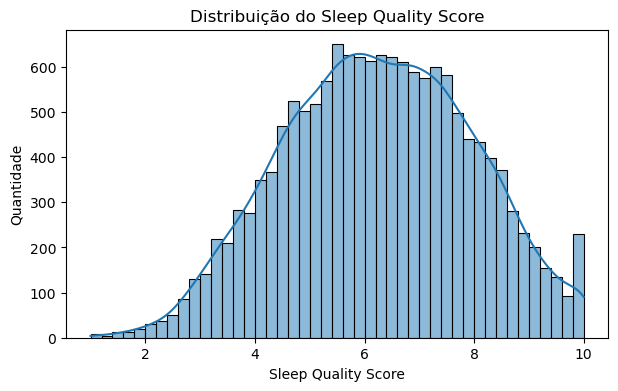

In [60]:
plt.figure(figsize=(7,4))
sns.histplot(mobile_df["sleep_quality_score"], kde=True)
plt.title("Distribuição do Sleep Quality Score")
plt.xlabel("Sleep Quality Score")
plt.ylabel("Quantidade")
plt.show()

### 4.2 Correlação das variáveis comportamentais

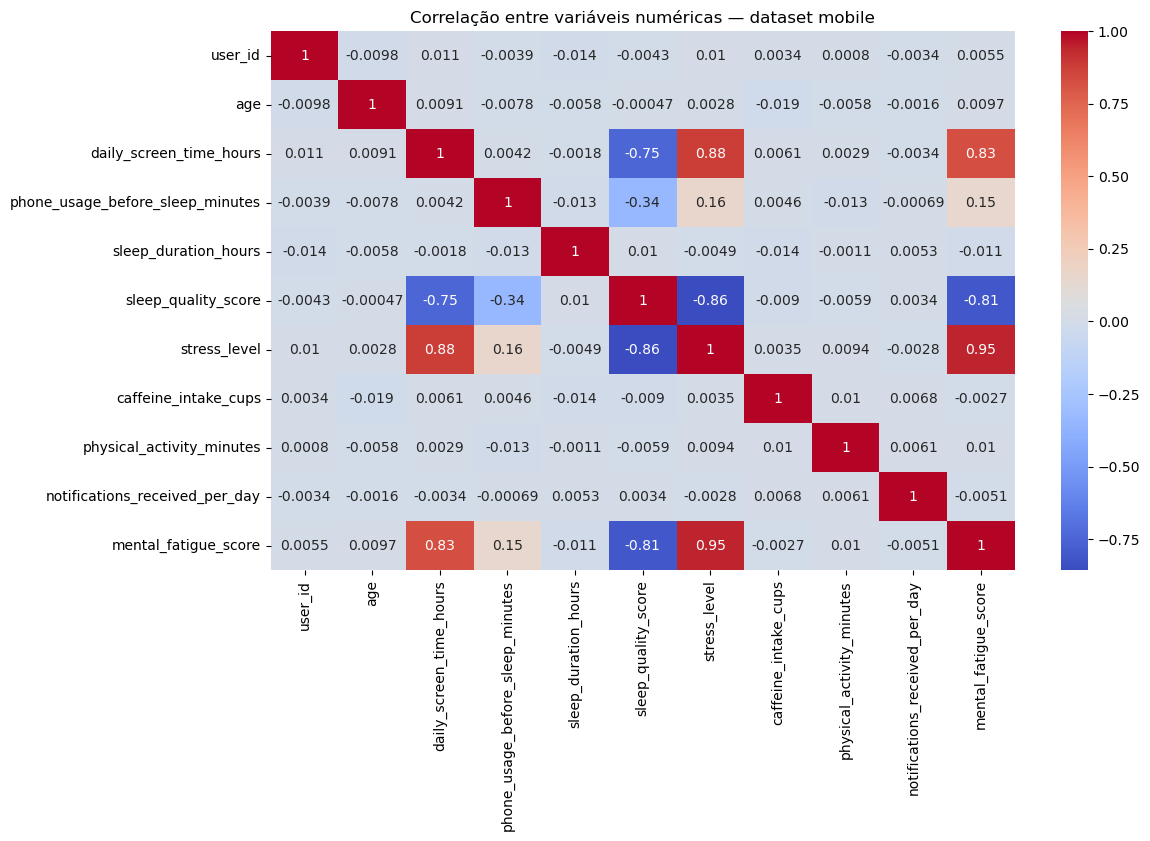

In [61]:
mobile_numeric = mobile_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,7))
sns.heatmap(mobile_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis numéricas — dataset mobile")
plt.show()

### 4.3 Conversão de hábitos para formato compatível com o app

No app, o consumo de cafeína será coletado como sim/não, e o uso do celular antes de dormir será coletado como sim/não + tempo de uso em minutos.

In [62]:
mobile_behavior = mobile_df.copy()
mobile_behavior["used_phone_before_sleep"] = (mobile_behavior["phone_usage_before_sleep_minutes"] > 0).astype(int)
mobile_behavior["consumed_caffeine"] = (mobile_behavior["caffeine_intake_cups"] > 0).astype(int)

mobile_behavior[[
    "phone_usage_before_sleep_minutes",
    "used_phone_before_sleep",
    "caffeine_intake_cups",
    "consumed_caffeine"
]].head()

,phone_usage_before_sleep_minutes,used_phone_before_sleep,caffeine_intake_cups,consumed_caffeine
0,86,1,0,0
1,32,1,0,0
2,107,1,0,0
3,36,1,0,0
4,56,1,4,1


## 5. Preparação do dataset combinado para classificação

A classificação utiliza:

- Dataset principal completo.
- Amostra de 500 registros do dataset mobile.
- Rótulos artificiais no dataset mobile para `Insomnia` e `No Disorder`, pois ele não possui `Sleep Disorder`.

Essa estratégia aumenta a quantidade de dados para treinamento.

In [63]:
MAX_MOBILE_ROWS = 500

def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df


def prepare_sleep_dataset(df):
    df = normalize_columns(df)
    df = df.drop(columns=["person_id"], errors="ignore")

    df["sleep_disorder"] = df["sleep_disorder"].fillna("No Disorder")
    df["bmi_category"] = df["bmi_category"].replace({"Normal": "Normal Weight"})

    bp_split = df["blood_pressure"].str.split("/", expand=True)
    df["bp_systolic"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["bp_diastolic"] = pd.to_numeric(bp_split[1], errors="coerce")
    df["bp_mean"] = (df["bp_systolic"] + (2 * df["bp_diastolic"])) / 3

    df["sleep_duration_hours"] = df["sleep_duration"]
    df["physical_activity_minutes"] = df["physical_activity_level"]

    df["used_phone_before_sleep"] = 0
    df["consumed_caffeine"] = 0
    df["consumed_alcohol"] = 0
    df["mental_fatigue_score"] = df["stress_level"]

    selected_cols = [
        "age", "gender", "occupation",
        "sleep_duration_hours", "quality_of_sleep", "stress_level",
        "physical_activity_minutes", "bmi_category", "heart_rate",
        "daily_steps", "bp_mean", "used_phone_before_sleep",
        "consumed_caffeine", "consumed_alcohol", "mental_fatigue_score",
        "sleep_disorder"
    ]

    return df[selected_cols]


def create_pseudo_label(row):
    sleep_quality = row["sleep_quality_score"]
    sleep_duration = row["sleep_duration_hours"]
    stress = row["stress_level"]
    fatigue = row["mental_fatigue_score"]

    if sleep_quality <= 4 and sleep_duration < 6.5 and stress >= 7:
        return "Insomnia"

    if sleep_quality <= 5 and fatigue >= 7 and stress >= 7:
        return "Insomnia"

    return "No Disorder"


def prepare_mobile_dataset(df):
    df = normalize_columns(df)
    df = df.sample(n=min(MAX_MOBILE_ROWS, len(df)), random_state=42)

    df["used_phone_before_sleep"] = (df["phone_usage_before_sleep_minutes"] > 0).astype(int)
    df["consumed_caffeine"] = (df["caffeine_intake_cups"] > 0).astype(int)
    df["consumed_alcohol"] = 0

    df["quality_of_sleep"] = df["sleep_quality_score"]
    df["bmi_category"] = "Unknown"
    df["heart_rate"] = pd.NA
    df["daily_steps"] = pd.NA
    df["bp_mean"] = pd.NA

    df["sleep_disorder"] = df.apply(create_pseudo_label, axis=1)

    selected_cols = [
        "age", "gender", "occupation",
        "sleep_duration_hours", "quality_of_sleep", "stress_level",
        "physical_activity_minutes", "bmi_category", "heart_rate",
        "daily_steps", "bp_mean", "used_phone_before_sleep",
        "consumed_caffeine", "consumed_alcohol", "mental_fatigue_score",
        "sleep_disorder"
    ]

    return df[selected_cols]


sleep_prepared = prepare_sleep_dataset(sleep_df)
mobile_prepared = prepare_mobile_dataset(mobile_df)
combined_df = pd.concat([sleep_prepared, mobile_prepared], ignore_index=True)

print("Shape dataset principal:", sleep_prepared.shape)
print("Shape dataset mobile:", mobile_prepared.shape)
print("Shape combinado:", combined_df.shape)
combined_df.head()

Shape dataset principal: (374, 16)
Shape dataset mobile: (500, 16)
Shape combinado: (874, 16)


C:\Users\Vinicius\AppData\Local\Temp\ipykernel_12940\4107559460.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([sleep_prepared, mobile_prepared], ignore_index=True)


,age,gender,occupation,sleep_duration_hours,quality_of_sleep,stress_level,physical_activity_minutes,bmi_category,heart_rate,daily_steps,bp_mean,used_phone_before_sleep,consumed_caffeine,consumed_alcohol,mental_fatigue_score,sleep_disorder
0,27,Male,Software Engineer,6.1,6.0,6.0,42,Overweight,77,4200,97.333333,0,0,0,6.0,No Disorder
1,28,Male,Doctor,6.2,6.0,8.0,60,Normal Weight,75,10000,95.000000,0,0,0,8.0,No Disorder
2,28,Male,Doctor,6.2,6.0,8.0,60,Normal Weight,75,10000,95.000000,0,0,0,8.0,No Disorder
3,28,Male,Sales Representative,5.9,4.0,8.0,30,Obese,85,3000,106.666667,0,0,0,8.0,Sleep Apnea
4,28,Male,Sales Representative,5.9,4.0,8.0,30,Obese,85,3000,106.666667,0,0,0,8.0,Sleep Apnea


### 5.1 Distribuição do alvo no dataset combinado

In [64]:
combined_df["sleep_disorder"].value_counts()

sleep_disorder
No Disorder    601
Insomnia       195
Sleep Apnea     78
Name: count, dtype: int64

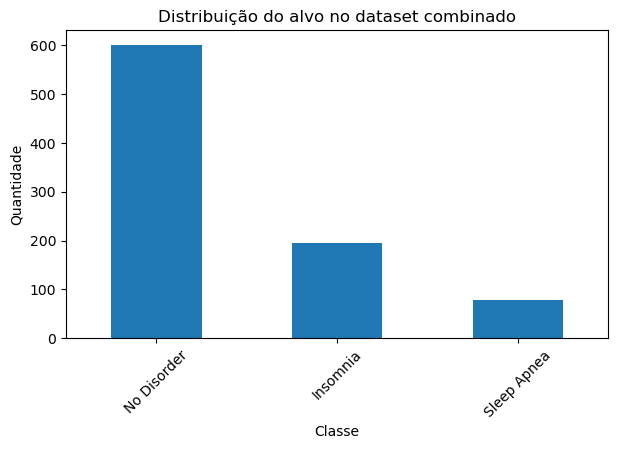

In [65]:
combined_df["sleep_disorder"].value_counts().plot(kind="bar", figsize=(7,4))
plt.title("Distribuição do alvo no dataset combinado")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

### 5.2 Pré-processamento do dataset combinado

As colunas numéricas foram mantidas como números. Apenas as colunas categóricas reais (`gender`, `occupation`, `bmi_category`) passam por one-hot encoding.

In [66]:
def preprocess_combined_data(df):
    df = df.copy()

    X = df.drop(columns=["sleep_disorder"])
    y = df["sleep_disorder"]

    numeric_cols = [
        "age", "sleep_duration_hours", "quality_of_sleep", "stress_level",
        "physical_activity_minutes", "heart_rate", "daily_steps", "bp_mean",
        "used_phone_before_sleep", "consumed_caffeine", "consumed_alcohol",
        "mental_fatigue_score"
    ]

    categorical_cols = ["gender", "occupation", "bmi_category"]

    for col in numeric_cols:
        if col in X.columns:
            X[col] = pd.to_numeric(X[col], errors="coerce")
            X[col] = X[col].fillna(X[col].median())

    for col in categorical_cols:
        if col in X.columns:
            X[col] = X[col].astype("str")
            X[col] = X[col].fillna("Unknown")

    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    return X, y

X_class, y_class = preprocess_combined_data(combined_df)

print("Shape de X:", X_class.shape)
print("Shape de y:", y_class.shape)
print(X_class.columns.tolist())

Shape de X: (874, 31)
Shape de y: (874,)
['age', 'sleep_duration_hours', 'quality_of_sleep', 'stress_level', 'physical_activity_minutes', 'heart_rate', 'daily_steps', 'bp_mean', 'used_phone_before_sleep', 'consumed_caffeine', 'consumed_alcohol', 'mental_fatigue_score', 'gender_Male', 'gender_Other', 'occupation_Designer', 'occupation_Doctor', 'occupation_Engineer', 'occupation_Freelancer', 'occupation_Lawyer', 'occupation_Manager', 'occupation_Nurse', 'occupation_Researcher', 'occupation_Sales Representative', 'occupation_Salesperson', 'occupation_Scientist', 'occupation_Software Engineer', 'occupation_Student', 'occupation_Teacher', 'bmi_category_Obese', 'bmi_category_Overweight', 'bmi_category_Unknown']


## 6. Treinamento e avaliação da classificação

Foram testados Random Forest e XGBoost. A escolha final considera principalmente a validação cruzada, pois ela é mais confiável que um único split de treino/teste.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, rf_pred))
print("Relatório Random Forest:")
print(classification_report(y_test, rf_pred))
print("Matriz de confusão Random Forest:")
print(confusion_matrix(y_test, rf_pred))

rf_scores = cross_val_score(rf_model, X_class, y_class, cv=5, scoring="accuracy")
print("Cross-validation Random Forest:")
print(rf_scores)
print("Média:", rf_scores.mean())

Accuracy Random Forest: 0.9542857142857143
Relatório Random Forest:
              precision    recall  f1-score   support

    Insomnia       0.93      0.97      0.95        39
 No Disorder       0.98      0.96      0.97       120
 Sleep Apnea       0.82      0.88      0.85        16

    accuracy                           0.95       175
   macro avg       0.91      0.94      0.92       175
weighted avg       0.96      0.95      0.95       175

Matriz de confusão Random Forest:
[[ 38   0   1]
 [  3 115   2]
 [  0   2  14]]
Cross-validation Random Forest:
[0.8        0.68       0.98857143 0.96571429 0.9137931 ]
Média: 0.869615763546798


In [68]:
if XGBOOST_AVAILABLE:
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_class)

    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
        X_class, y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="mlogloss"
    )

    xgb_model.fit(X_train_xgb, y_train_xgb)
    xgb_pred = xgb_model.predict(X_test_xgb)

    print("Accuracy XGBoost:", accuracy_score(y_test_xgb, xgb_pred))
    print("Relatório XGBoost:")
    print(classification_report(y_test_xgb, xgb_pred, target_names=le.classes_))
    print("Matriz de confusão XGBoost:")
    print(confusion_matrix(y_test_xgb, xgb_pred))

    xgb_scores = cross_val_score(xgb_model, X_class, y_encoded, cv=5, scoring="accuracy")
    print("Cross-validation XGBoost:")
    print(xgb_scores)
    print("Média:", xgb_scores.mean())
else:
    print("XGBoost não instalado. Instale com: pip install xgboost")

Accuracy XGBoost: 0.9771428571428571
Relatório XGBoost:
              precision    recall  f1-score   support

    Insomnia       0.97      0.97      0.97        39
 No Disorder       0.98      0.99      0.99       120
 Sleep Apnea       0.93      0.88      0.90        16

    accuracy                           0.98       175
   macro avg       0.96      0.95      0.96       175
weighted avg       0.98      0.98      0.98       175

Matriz de confusão XGBoost:
[[ 38   0   1]
 [  1 119   0]
 [  0   2  14]]
Cross-validation XGBoost:
[0.81142857 0.45714286 0.99428571 0.93142857 0.95977011]
Média: 0.8308111658456486


In [69]:
pip install xgboost

### 6.1 Importância das variáveis da classificação

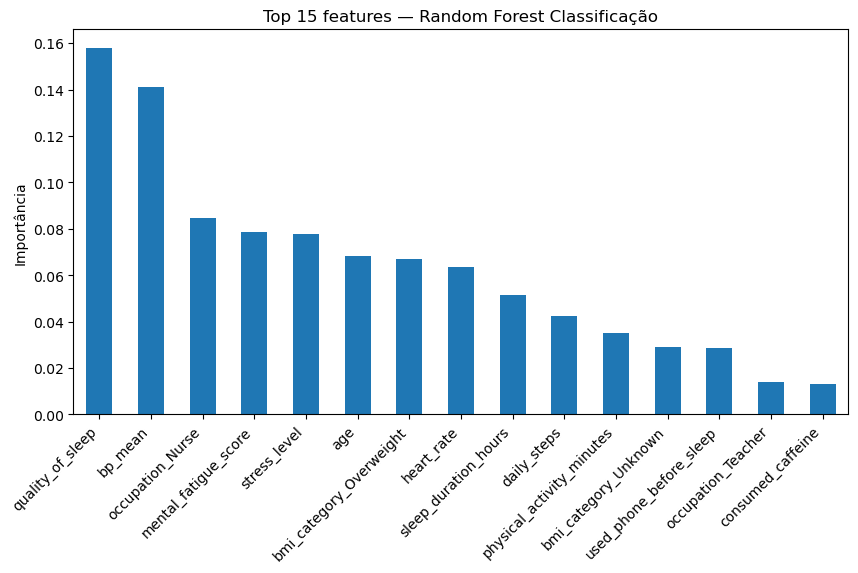

quality_of_sleep             0.157989
bp_mean                      0.141044
occupation_Nurse             0.084791
mental_fatigue_score         0.078436
stress_level                 0.077782
age                          0.068103
bmi_category_Overweight      0.067012
heart_rate                   0.063372
sleep_duration_hours         0.051349
daily_steps                  0.042586
physical_activity_minutes    0.034904
bmi_category_Unknown         0.029296
used_phone_before_sleep      0.028547
occupation_Teacher           0.014172
consumed_caffeine            0.013085
dtype: float64

In [70]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_class.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importances.head(15).plot(kind="bar")
plt.title("Top 15 features — Random Forest Classificação")
plt.ylabel("Importância")
plt.xticks(rotation=45, ha="right")
plt.show()

feature_importances.head(15)

## 7. Regressão para estimar o score de sono

A regressão utiliza apenas o dataset mobile/comportamental, pois ele possui o alvo `sleep_quality_score` e variáveis relacionadas a hábitos diários.

In [71]:
reg_df = mobile_df.copy()
reg_df.columns = (
    reg_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

target = "sleep_quality_score"
reg_df = reg_df.dropna(subset=[target])

reg_df["phone_usage_before_sleep_minutes"] = pd.to_numeric(
    reg_df["phone_usage_before_sleep_minutes"],
    errors="coerce"
)

reg_df["used_phone_before_sleep"] = (
    reg_df["phone_usage_before_sleep_minutes"] > 0
).astype(int)

reg_df["consumed_caffeine"] = (
    reg_df["caffeine_intake_cups"] > 0
).astype(int)

cols_to_drop = [
    target,
    "user_id",
    "caffeine_intake_cups",
    "daily_screen_time_hours",
    "notifications_received_per_day"
]

X_reg = reg_df.drop(columns=cols_to_drop, errors="ignore")
y_reg = reg_df[target]

numeric_cols = X_reg.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_reg.select_dtypes(include=["object", "bool", "category"]).columns

for col in numeric_cols:
    X_reg[col] = X_reg[col].fillna(X_reg[col].median())

for col in categorical_cols:
    if not X_reg[col].mode().empty:
        X_reg[col] = X_reg[col].fillna(X_reg[col].mode()[0])

X_reg = pd.get_dummies(X_reg, drop_first=True)

print("Shape de X_reg:", X_reg.shape)
print("Shape de y_reg:", y_reg.shape)
print(X_reg.columns.tolist())

Shape de X_reg: (15000, 17)
Shape de y_reg: (15000,)
['age', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'stress_level', 'physical_activity_minutes', 'mental_fatigue_score', 'used_phone_before_sleep', 'consumed_caffeine', 'gender_Male', 'gender_Other', 'occupation_Doctor', 'occupation_Freelancer', 'occupation_Manager', 'occupation_Researcher', 'occupation_Software Engineer', 'occupation_Student', 'occupation_Teacher']


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

reg_model = RandomForestRegressor(
    n_estimators=300,
    random_state=10
)

reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

reg_scores = cross_val_score(reg_model, X_reg, y_reg, cv=5, scoring="r2")
print("Cross-validation R²:")
print(reg_scores)
print("Média R²:", reg_scores.mean())

MAE: 0.6222365888888889
RMSE: 0.7840377872892399
R²: 0.7887585939248402
Cross-validation R²:
[0.78886004 0.78162079 0.78185495 0.78494322 0.78613387]
Média R²: 0.7846825736741327


### 7.1 Importância das variáveis da regressão

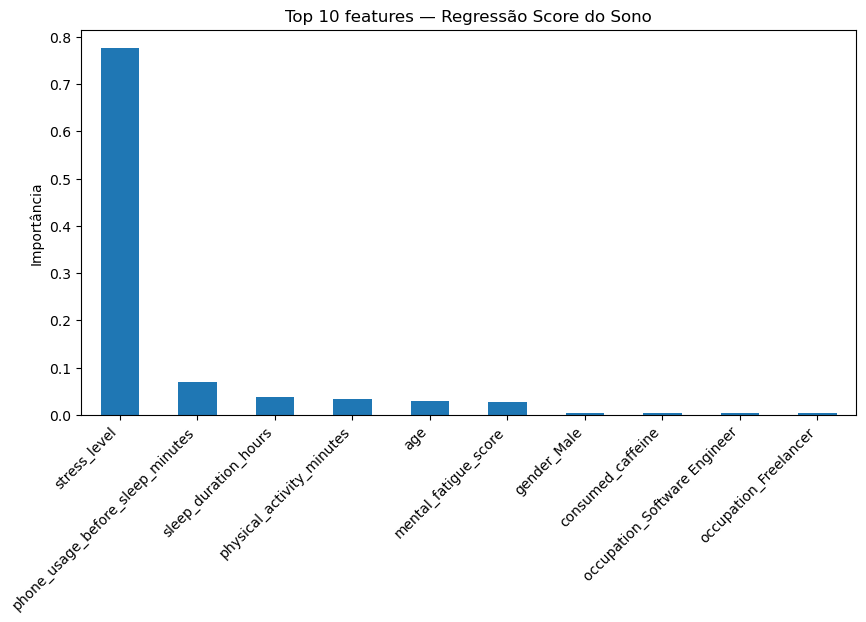

stress_level                        0.776357
phone_usage_before_sleep_minutes    0.068567
sleep_duration_hours                0.037050
physical_activity_minutes           0.032783
age                                 0.028215
mental_fatigue_score                0.026528
gender_Male                         0.004316
consumed_caffeine                   0.003523
occupation_Software Engineer        0.003207
occupation_Freelancer               0.003136
dtype: float64

In [73]:
reg_importances = pd.Series(reg_model.feature_importances_, index=X_reg.columns)
reg_importances = reg_importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))
reg_importances.head(10).plot(kind="bar")
plt.title("Top 10 features — Regressão Score do Sono")
plt.ylabel("Importância")
plt.xticks(rotation=45, ha="right")
plt.show()

reg_importances.head(10)

## 8. Conclusões da análise

- O modelo de **classificação** foi treinado com datasets combinados, utilizando dados fisiológicos, de sono e comportamentais.
- A pressão arterial foi simplificada em `bp_mean`, mantendo bom desempenho e reduzindo complexidade.
- A combinação de datasets aumentou a base de treinamento.
- O modelo de **regressão** foi treinado apenas com o dataset mobile, por possuir o alvo `sleep_quality_score`.
- Para a regressão, manter `used_phone_before_sleep` e `phone_usage_before_sleep_minutes` melhorou o desempenho em relação ao uso apenas do campo sim/não.
- A classificação é mais voltada à identificação de distúrbios, enquanto a regressão é mais voltada à estimativa da qualidade do sono a partir de hábitos diários.